### Load & Merge Data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [2]:
train_df = pd.read_csv(r"F:\siva\Hyderabad _ ML\Project\Marketing Revenue Prediction System (KNN-Based)\Datasets\train.csv")
test_df = pd.read_csv(r"F:\siva\Hyderabad _ ML\Project\Marketing Revenue Prediction System (KNN-Based)\Datasets\test.csv")

missing_cols = set(train_df.columns) - set(test_df.columns)
missing_cols

{'sales_revenue'}

In [3]:
for col in missing_cols:
    test_df[col] = np.nan
test_df = test_df[train_df.columns]

df = pd.concat([train_df,test_df],ignore_index=True)

print("Shape :",df.shape)
df.head()

Shape : (24000, 17)


,id,date,region,channel,product_category,customer_segment,ad_spend,price,discount_rate,market_reach,impressions,click_through_rate,competition_index,seasonality_index,campaign_duration_days,customer_lifetime_value,sales_revenue
0,1,05-12-2011 11.31,Nort,Search,General,Standard,9.00,0.75,0.2782,32.0,817,0.0010,3.34,1.000000,30.0,816.49,119.767811
1,2,27-04-2011 14.01,North,Social Media,General,Premium,3.35,3.35,0.0912,61.0,2289,0.0640,4.44,0.366025,90.0,1723.16,119.404661
2,3,09-11-2010 15.20,North,Affiliate,General,Budget,2.55,2.55,0.1997,461.0,14697,0.1508,3.31,0.366025,21.0,1151.74,132.009747
3,4,03-10-2010 15.24,North,Affiliate,Storage,Premium,2.95,2.95,0.4767,744.0,17578,0.1965,2.87,-0.366025,90.0,3585.85,154.511756
4,5,14-10-2011 9.28,North,Search,Lighting,Premium,15.00,1.25,0.3536,226.0,6280,0.0200,7.40,-0.366025,90.0,502.28,128.059924


In [4]:
df.tail()

,id,date,region,channel,product_category,customer_segment,ad_spend,price,discount_rate,market_reach,impressions,click_through_rate,competition_index,seasonality_index,campaign_duration_days,customer_lifetime_value,sales_revenue
23995,23996,14-10-2010 16.14,North,Social Media,General,Standard,3.30,1.65,0.0629,591.0,3737,0.0582,3.92,-0.366025,21.0,61.54,NaN
23996,23997,01-12-2010 11.57,North,Affiliate,General,Premium,3.48,0.29,0.6000,275.0,8725,0.0291,4.17,1.000000,21.0,3072.86,NaN
23997,23998,25-03-2010 16.33,North,Email,General,Premium,21.30,10.65,NaN,91.0,1723,0.0105,NaN,1.000000,60.0,995.19,NaN
23998,23999,29-10-2010 12.07,North,Social Media,Storage,Premium,45.00,1.25,0.1014,43.0,1046,0.1632,6.53,-0.366025,14.0,9856.05,NaN
23999,24000,20-10-2010 13.11,North,Search,Storage,Standard,35.80,8.95,0.1059,241.0,1809,0.0291,6.86,-0.366025,7.0,220.36,NaN


### =========================== EDA ===================================

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       24000 non-null  int64  
 1   date                     24000 non-null  object 
 2   region                   24000 non-null  object 
 3   channel                  24000 non-null  object 
 4   product_category         24000 non-null  object 
 5   customer_segment         24000 non-null  object 
 6   ad_spend                 23113 non-null  float64
 7   price                    24000 non-null  float64
 8   discount_rate            22965 non-null  float64
 9   market_reach             23079 non-null  float64
 10  impressions              24000 non-null  int64  
 11  click_through_rate       23025 non-null  float64
 12  competition_index        23047 non-null  float64
 13  seasonality_index        24000 non-null  float64
 14  campaign_duration_days

In [6]:
df.isnull().sum()

id                            0
date                          0
region                        0
channel                       0
product_category              0
customer_segment              0
ad_spend                    887
price                         0
discount_rate              1035
market_reach                921
impressions                   0
click_through_rate          975
competition_index           953
seasonality_index             0
campaign_duration_days     1962
customer_lifetime_value    1008
sales_revenue              6000
dtype: int64

In [7]:
df.describe()

,id,ad_spend,price,discount_rate,market_reach,impressions,click_through_rate,competition_index,seasonality_index,campaign_duration_days,customer_lifetime_value,sales_revenue
count,24000.000000,23113.000000,24000.000000,22965.000000,23079.000000,24000.000000,23025.000000,23047.00000,24000.000000,22038.000000,22992.000000,18000.000000
mean,12000.500000,44.277368,5.547053,0.229198,321.841674,7273.284708,0.056933,4.00224,-0.016105,35.744941,10509.835886,137.204937
std,6928.347566,189.884213,21.887603,0.149601,245.478543,7603.662368,0.049310,1.99959,0.919990,27.086134,36421.833930,54.961808
min,1.000000,0.001000,0.001000,0.000200,1.000000,-30771.000000,0.000000,0.03000,-1.366025,7.000000,0.001000,0.000000
25%,6000.750000,4.950000,1.250000,0.109000,139.000000,2497.000000,0.020300,2.43000,-1.000000,14.000000,570.412500,100.088209
50%,12000.500000,12.450000,1.950000,0.202500,269.000000,5115.500000,0.043300,3.86000,0.366025,28.000000,1775.570000,129.113361
75%,18000.250000,19.800000,3.750000,0.324100,439.000000,9608.500000,0.079800,5.43000,1.000000,60.000000,5453.470000,164.688454
max,24000.000000,4254.500000,295.000000,0.600000,1490.000000,173986.000000,0.435700,9.65000,1.366025,90.000000,594023.990000,684.320270


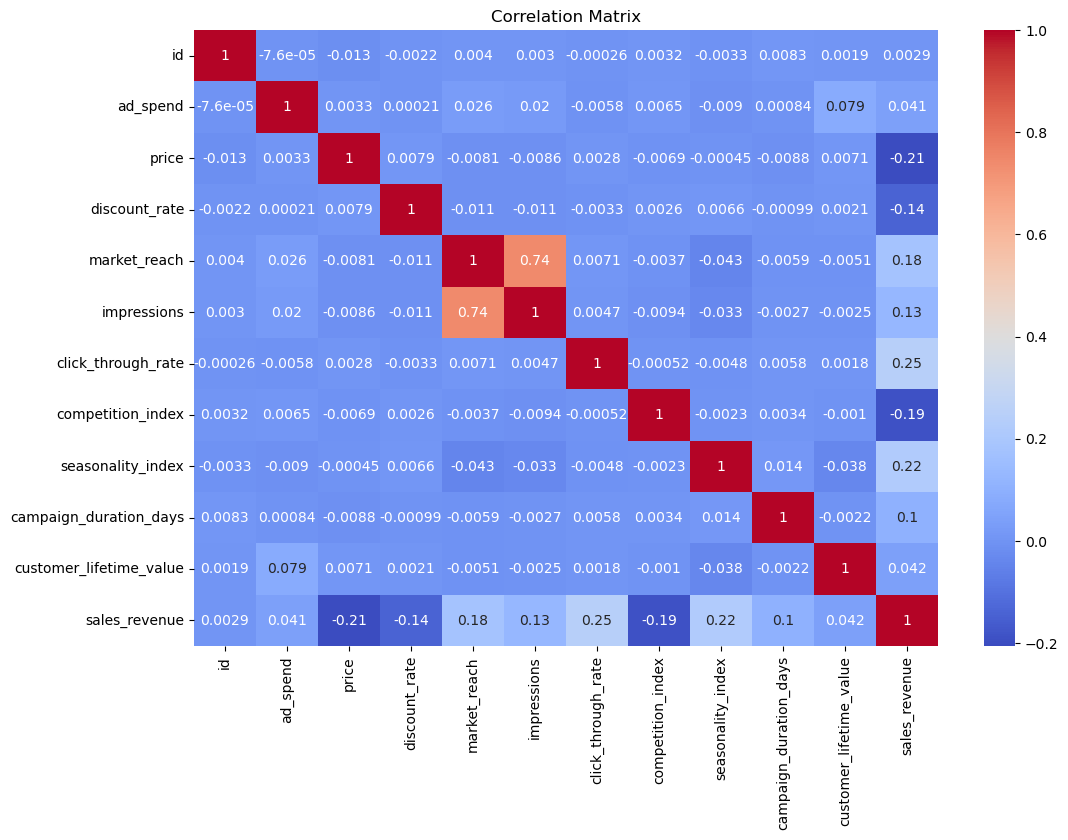

In [8]:
# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

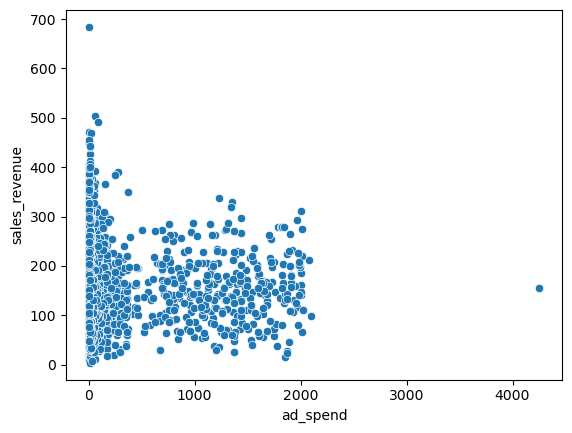

In [9]:
# Ad Spend vs Revenue
sns.scatterplot(x=df["ad_spend"], y=df["sales_revenue"])
plt.show()

### ===================== Data Preprocessing ================================

In [10]:
# Numerical columns
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categorical columns
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [11]:
df.isna().sum()

id                         0
date                       0
region                     0
channel                    0
product_category           0
customer_segment           0
ad_spend                   0
price                      0
discount_rate              0
market_reach               0
impressions                0
click_through_rate         0
competition_index          0
seasonality_index          0
campaign_duration_days     0
customer_lifetime_value    0
sales_revenue              0
dtype: int64

In [12]:
# Encode Categorical Features

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for i in cat_cols:
    df[i] = le.fit_transform(df[i])

In [13]:
df.head()

,id,date,region,channel,product_category,customer_segment,ad_spend,price,discount_rate,market_reach,impressions,click_through_rate,competition_index,seasonality_index,campaign_duration_days,customer_lifetime_value,sales_revenue
0,1,2342,4,3,0,2,9.00,0.75,0.2782,32.0,817,0.0010,3.34,1.000000,30.0,816.49,119.767811
1,2,12561,5,5,0,1,3.35,3.35,0.0912,61.0,2289,0.0640,4.44,0.366025,90.0,1723.16,119.404661
2,3,4360,5,0,0,0,2.55,2.55,0.1997,461.0,14697,0.1508,3.31,0.366025,21.0,1151.74,132.009747
3,4,1198,5,0,5,1,2.95,2.95,0.4767,744.0,17578,0.1965,2.87,-0.366025,90.0,3585.85,154.511756
4,5,6724,5,3,2,1,15.00,1.25,0.3536,226.0,6280,0.0200,7.40,-0.366025,90.0,502.28,128.059924


In [14]:
train_df1 = df[df["sales_revenue"].notna()]
test_df1 = df[df["sales_revenue"].isna()]

In [15]:
train_df1.shape

(24000, 17)

In [16]:
# Features & Target

X = train_df1.drop("sales_revenue", axis=1)
y = train_df1["sales_revenue"]

In [17]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [18]:
# Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train  = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
# Model Building

from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor(n_neighbors=14)

model.fit(X_train,y_train)

KNeighborsRegressor(n_neighbors=14)

In [29]:
y_pred = knn.predict(X_test)
y_pred

array([126.03507562, 126.65273824, 132.56557047, ..., 126.75622114,
       149.63077856, 143.90816438])

In [30]:
# Model Evaluation
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 29.447410663916635
MSE: 1857.0149000106064
RMSE: 43.09309573482284
R2 Score: 0.22722244745979503


In [31]:
import pickle
import os

os.makedirs("models", exist_ok=True)

with open("models/knn_model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)